In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer # fills missing values with your desired values { mean,mode,median,constant,etc }

# from sklearn

In [2]:
df = pd.read_csv("loan_approval_data.csv")
# df.head
df.isnull().sum()
df.describe

<bound method NDFrame.describe of      Applicant_ID  Applicant_Income  Coapplicant_Income Employment_Status  \
0             1.0           17795.0              1387.0          Salaried   
1             2.0            2860.0              2679.0          Salaried   
2             3.0            7390.0              2106.0          Salaried   
3             4.0           13964.0              8173.0          Salaried   
4             5.0           13284.0              4223.0     Self-employed   
..            ...               ...                 ...               ...   
995         996.0               NaN              9092.0          Salaried   
996         997.0            3279.0              6356.0     Self-employed   
997         998.0           15192.0              8433.0          Contract   
998         999.0            9083.0              7380.0        Unemployed   
999        1000.0           13093.0              2385.0          Salaried   

      Age Marital_Status  Dependents  Cre

In [3]:
# DATA FILTERING
# df.fillna(df.mean(numeric_only=True))
categorical_col = df.select_dtypes(include=["object"]).columns
numerical_col = df.select_dtypes(include=["number"]).columns

C:\Users\Jitesh\AppData\Local\Temp\ipykernel_88312\2231274257.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include=["object"]).columns


In [4]:
num_imp = SimpleImputer(strategy="mean")
df[numerical_col] = num_imp.fit_transform(df[numerical_col])
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_col] = cat_imp.fit_transform(df[categorical_col])
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


Text(0.5, 1.0, 'is loan approved or not')

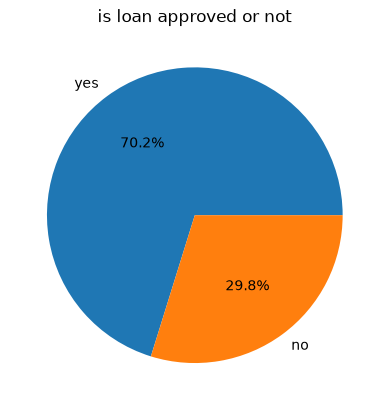

In [5]:
# EDA exploratory data analysis 
classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels= ["yes","no"], autopct="%1.1f%%")
plt.title("is loan approved or not")

Text(0.5, 1.0, 'purpose of taking loan')

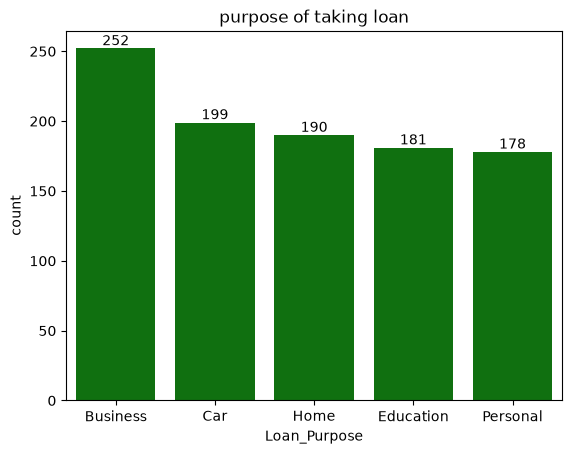

In [6]:
loan_pur_count = df["Loan_Purpose"].value_counts()
lc = sns.barplot(loan_pur_count,color = "green")
lc.bar_label(lc.containers[0])
lc.set_title("purpose of taking loan")

Text(0.5, 1.0, 'Marital_Status')

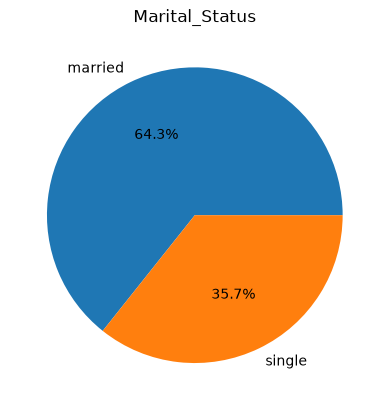

In [7]:
classes_count = df["Marital_Status"].value_counts()
plt.pie(classes_count, labels= ["married","single"], autopct="%1.1f%%")
plt.title("Marital_Status")